In [ ]:
#pip install torch torchvision torchaudio --break-system-packages

In [1]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive monté !")

Mounted at /content/drive
Google Drive monté !


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# CELLULE 2 : Vérifier que les fichiers sont bien là
# ===================================================
import os

# Chemin vers ton dossier H&M dans Drive
drive_folder = '/content/drive/MyDrive/data'

print("📂 Fichiers disponibles dans Drive :")
print("="*60)

for f in sorted(os.listdir(drive_folder)):
    filepath = os.path.join(drive_folder, f)
    if os.path.isfile(filepath):
        size = os.path.getsize(filepath) / (1024**3)  # En GB
        print(f"  📄 {f:<45} {size:>8.2f} GB")
    else:
        print(f"  📁 {f}/")

print("="*60)

📂 Fichiers disponibles dans Drive :
  📄 sample_submission.csv                             0.25 GB
  📄 submission.csv                                    0.24 GB
  📄 transactions_train.csv                            3.25 GB


In [38]:
# CELLULE 3 : Charger les données
# ================================
import pandas as pd

# Chemins complets
transactions_path = '/content/drive/MyDrive/data/transactions_train.csv'
sample_submission_path = '/content/drive/MyDrive/data/sample_submission.csv'

# Charger les données
print(" Chargement des données depuis Drive...")

# Transactions (gros fichier - peut prendre 1-2 minutes)
print("   Loading transactions_train.csv...")
transactions = pd.read_csv(transactions_path, parse_dates=['t_dat'])




 Chargement des données depuis Drive...
   Loading transactions_train.csv...


In [39]:
print("   Loading sample_submission.csv...")
sample_submission = pd.read_csv(sample_submission_path)

print(" Toutes les données chargées !")

# Afficher les infos
print(" Informations sur les datasets :")
print("="*60)
print(f"Transactions : {len(transactions):,} lignes")
print(f"Submission   : {len(sample_submission):,} lignes")
print("="*60)

   Loading sample_submission.csv...
 Toutes les données chargées !
 Informations sur les datasets :
Transactions : 31,788,324 lignes
Submission   : 1,371,980 lignes


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import deque, defaultdict
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datetime import timedelta
import warnings
import heapq
import itertools
warnings.filterwarnings('ignore')

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Load Data

In [41]:


print(f"\nSample submission loaded:")
print(f"  Shape: {sample_submission.shape}")
print(f"  Columns: {sample_submission.columns.tolist()}")
print(f"\nFirst few rows:")
print(sample_submission.head())

# Liste complete des customer_id a predire
all_customers = sample_submission['customer_id'].tolist()
print(f"\nTotal customers to predict for: {len(all_customers)}")

target_customers = set(sample_submission['customer_id'].values)
print(f"   Target customers to prioritize: {len(target_customers):,}")


Sample submission loaded:
  Shape: (1371980, 2)
  Columns: ['customer_id', 'prediction']

First few rows:
                                         customer_id  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...   

                                          prediction  
0  0706016001 0706016002 0372860001 0610776002 07...  
1  0706016001 0706016002 0372860001 0610776002 07...  
2  0706016001 0706016002 0372860001 0610776002 07...  
3  0706016001 0706016002 0372860001 0610776002 07...  
4  0706016001 0706016002 0372860001 0610776002 07...  

Total customers to predict for: 1371980
   Target customers to prioritize: 1,371,980


In [42]:
# ==========================================
# FILTRER LES 4 DERNIÈRES TRANSACTIONS PAR CUSTOMER
# ==========================================
import pandas as pd
from collections import defaultdict
from tqdm.auto import tqdm
import gc

print(f"   Total transactions: {len(transactions):,}")
print(f"   Unique customers: {transactions['customer_id'].nunique():,}")
print(f"   Date range: {transactions['t_dat'].min()} to {transactions['t_dat'].max()}")

# ==========================================
# ETAPE 1: Filtrer seulement les target customers
# ==========================================
print("\n1. Filtering transactions for target customers...")

transactions_filtered = transactions[transactions['customer_id'].isin(target_customers)].copy()

print(f"   Transactions après filtre: {len(transactions_filtered):,}")
print(f"   Customers couverts: {transactions_filtered['customer_id'].nunique():,}")

# Libérer mémoire de l'ancien dataset (optionnel)
del transactions
gc.collect()

# ==========================================
# ETAPE 2: Garder les 4 dernières transactions par customer
# ==========================================
print("\n2. Keeping last 4 transactions per customer...")

# Trier par customer et date
transactions_filtered = transactions_filtered.sort_values(['customer_id', 't_dat'])

# Garder les 4 dernières transactions par customer
transactions_final = (
    transactions_filtered
    .groupby('customer_id')
    .tail(20)  #  Garde les 4 dernières lignes de chaque groupe
    .reset_index(drop=True)
)

print(f"   Transactions après sélection: {len(transactions_final):,}")

# Libérer mémoire
del transactions_filtered
gc.collect()

# Renommer pour la suite
transactions = transactions_final
del transactions_final

# ==========================================
# ETAPE 3: STATISTIQUES FINALES
# ==========================================
print("\n" + "="*60)
print("FINAL STATISTICS")
print("="*60)
print(f"\nTotal transactions: {len(transactions):,}")
print(f"Unique customers: {transactions['customer_id'].nunique():,}")
print(f"Unique articles: {transactions['article_id'].nunique():,}")
print(f"Date range: {transactions['t_dat'].min()} to {transactions['t_dat'].max()}")

# Vérifier couverture
target_customers_covered = len(set(transactions['customer_id']).intersection(target_customers))
coverage = target_customers_covered / len(target_customers) * 100

print(f"\nTarget customer coverage:")
print(f"  Customers in sample_submission: {len(target_customers):,}")
print(f"  Customers with transactions in data: {target_customers_covered:,}")
print(f"  Coverage: {coverage:.2f}%")

print(f"\nTransactions per customer:")
txn_per_customer = transactions.groupby('customer_id').size()
print(f"  Mean: {txn_per_customer.mean():.1f}")
print(f"  Median: {txn_per_customer.median():.1f}")
print(f"  Min: {txn_per_customer.min()}")
print(f"  Max: {txn_per_customer.max()}")

# Distribution
print(f"\nDistribution of transactions per customer:")
distribution = txn_per_customer.value_counts().sort_index()
for num_txns, count in distribution.items():
    print(f"  {num_txns} transaction(s): {count:,} customers")

print("\n" + "="*60)
print(" TRANSACTIONS FILTERED SUCCESSFULLY")
print("="*60)
print(f"\nGuarantee: Each customer has up to 4 most recent transactions!")

# ==========================================
# BONUS: Sauvegarder pour réutilisation future
# ==========================================
'''
print("\n Saving filtered transactions to Drive...")

output_path = '/content/drive/MyDrive/data/transactions_last4_per_customer.parquet'
transactions.to_parquet(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"   File size: {os.path.getsize(output_path) / (1024**2):.2f} MB")
print(" Next time, load directly with:")
print("   transactions = pd.read_parquet('{output_path}')")
'''

   Total transactions: 31,788,324
   Unique customers: 1,362,281
   Date range: 2018-09-20 00:00:00 to 2020-09-22 00:00:00

1. Filtering transactions for target customers...
   Transactions après filtre: 31,788,324
   Customers couverts: 1,362,281

2. Keeping last 4 transactions per customer...
   Transactions après sélection: 14,745,807

FINAL STATISTICS

Total transactions: 14,745,807
Unique customers: 1,362,281
Unique articles: 98,554
Date range: 2018-09-20 00:00:00 to 2020-09-22 00:00:00

Target customer coverage:
  Customers in sample_submission: 1,371,980
  Customers with transactions in data: 1,362,281
  Coverage: 99.29%

Transactions per customer:
  Mean: 10.8
  Median: 9.0
  Min: 1
  Max: 20

Distribution of transactions per customer:
  1 transaction(s): 131,514 customers
  2 transaction(s): 127,441 customers
  3 transaction(s): 95,686 customers
  4 transaction(s): 82,082 customers
  5 transaction(s): 64,635 customers
  6 transaction(s): 56,820 customers
  7 transaction(s): 47

'\nprint("\n Saving filtered transactions to Drive...")\n\noutput_path = \'/content/drive/MyDrive/data/transactions_last4_per_customer.parquet\'\ntransactions.to_parquet(output_path, index=False)\n\nprint(f"Saved to: {output_path}")\nprint(f"   File size: {os.path.getsize(output_path) / (1024**2):.2f} MB")\nprint(" Next time, load directly with:")\nprint("   transactions = pd.read_parquet(\'{output_path}\')")\n'

Temporal Split - CRITIQUE POUR H&M

In [43]:
# MODIFICATION 1: Split temporel avec fenetre de 7 jours
print("Creating temporal train/test split...")

# Derniere date dans les donnees
max_date = transactions['t_dat'].max()
print(f"Latest transaction date: {max_date}")

# Split: derniers 7 jours pour test
test_start_date = max_date - timedelta(days=6)  # 7 jours inclus
train_end_date = test_start_date - timedelta(days=1)

print(f"Train period: up to {train_end_date}")
print(f"Test period: {test_start_date} to {max_date}")

# Separer train et test
train_transactions = transactions[transactions['t_dat'] <= train_end_date].copy()
test_transactions = transactions[transactions['t_dat'] > train_end_date].copy()

print(f"\nTrain transactions: {len(train_transactions)}")
print(f"Test transactions: {len(test_transactions)}")
print(f"Test users: {test_transactions['customer_id'].nunique()}")

Creating temporal train/test split...
Latest transaction date: 2020-09-22 00:00:00
Train period: up to 2020-09-15 00:00:00
Test period: 2020-09-16 00:00:00 to 2020-09-22 00:00:00

Train transactions: 14508444
Test transactions: 237363
Test users: 68984


In [44]:
print(f"Train users: {train_transactions['customer_id'].nunique()}")

Train users: 1356286


In [45]:
print("\n" + "="*60)
print("TRAIN/TEST CUSTOMER OVERLAP ANALYSIS")
print("="*60)

# Customers uniques dans train et test
train_customers = set(train_transactions['customer_id'].unique())
test_customers = set(test_transactions['customer_id'].unique())

# Calculer le chevauchement
overlap_customers = train_customers.intersection(test_customers)
test_only_customers = test_customers - train_customers
train_only_customers = train_customers - test_customers

print(f"\n1. TRAIN SET:")
print(f"   Unique customers: {len(train_customers):,}")

print(f"\n2. TEST SET:")
print(f"   Unique customers: {len(test_customers):,}")

print(f"\n3. OVERLAP:")
print(f"   Customers in BOTH train and test: {len(overlap_customers):,}")
print(f"   Percentage of test customers with history: {len(overlap_customers)/len(test_customers)*100:.2f}%")

print(f"\n4. CUSTOMERS ONLY IN TEST (cold start):")
print(f"   Count: {len(test_only_customers):,}")
print(f"   Percentage: {len(test_only_customers)/len(test_customers)*100:.2f}%")

print(f"\n5. CUSTOMERS ONLY IN TRAIN:")
print(f"   Count: {len(train_only_customers):,}")

# Verifier avec sample_submission
sample_customers = set(sample_submission['customer_id'].values)

test_in_sample = test_customers.intersection(sample_customers)
overlap_in_sample = overlap_customers.intersection(sample_customers)

print(f"\n6. SAMPLE_SUBMISSION PERSPECTIVE:")
print(f"   Test customers also in sample_submission: {len(test_in_sample):,}")
print(f"   Of those, how many have train history: {len(overlap_in_sample):,} ({len(overlap_in_sample)/len(test_in_sample)*100:.2f}%)")

print("\n" + "="*60)



TRAIN/TEST CUSTOMER OVERLAP ANALYSIS

1. TRAIN SET:
   Unique customers: 1,356,286

2. TEST SET:
   Unique customers: 68,984

3. OVERLAP:
   Customers in BOTH train and test: 62,989
   Percentage of test customers with history: 91.31%

4. CUSTOMERS ONLY IN TEST (cold start):
   Count: 5,995
   Percentage: 8.69%

5. CUSTOMERS ONLY IN TRAIN:
   Count: 1,293,297

6. SAMPLE_SUBMISSION PERSPECTIVE:
   Test customers also in sample_submission: 68,984
   Of those, how many have train history: 62,989 (91.31%)



Data Preparation

In [46]:
# Creer sequences utilisateur pour train
print("\nCreating user sequences...")

train_sorted = train_transactions.sort_values(['customer_id', 't_dat'])
user_sequences = train_sorted.groupby('customer_id')['article_id'].apply(list).to_dict()

print(f"Created sequences for {len(user_sequences)} users")
print(f"Average sequence length: {np.mean([len(s) for s in user_sequences.values()]):.1f}")


Creating user sequences...
Created sequences for 1356286 users
Average sequence length: 10.7


In [47]:
# MODIFICATION 2: Creer targets = TOUS les articles achetes dans test (pas juste 1)
print("\nCreating test targets...")

test_targets = test_transactions.groupby('customer_id')['article_id'].apply(list).to_dict()

print(f"Test users with targets: {len(test_targets)}")
print(f"Average items purchased in test period: {np.mean([len(items) for items in test_targets.values()]):.1f}")

# Distribution du nombre d'achats
items_per_user = [len(items) for items in test_targets.values()]
print(f"Min items: {min(items_per_user)}, Max items: {max(items_per_user)}")


Creating test targets...
Test users with targets: 68984
Average items purchased in test period: 3.4
Min items: 1, Max items: 20


In [48]:
# Create article encoding
unique_articles = train_transactions['article_id'].unique()
article_to_idx = {art: idx + 1 for idx, art in enumerate(unique_articles)}
idx_to_article = {idx: art for art, idx in article_to_idx.items()}
num_items = len(article_to_idx) + 1

print(f"\nTotal unique articles in train: {len(unique_articles)}")
print(f"Vocabulary size with padding: {num_items}")


Total unique articles in train: 97882
Vocabulary size with padding: 97883


In [49]:
# Preparer donnees d'entrainement
print("\nPreparing training data...")

train_seqs = []
train_targets = []

for user_id, seq in user_sequences.items():
    if len(seq) < 3:
        continue

    encoded_seq = [article_to_idx[art] for art in seq if art in article_to_idx]

    if len(encoded_seq) < 3:
        continue

    # Creer samples d'entrainement: predire chaque item suivant
    for i in range(1, len(encoded_seq)):
        train_seqs.append(encoded_seq[:i])
        train_targets.append(encoded_seq[i])

print(f"Training samples created: {len(train_seqs)}")


Preparing training data...
Training samples created: 13025271


Model Definition

In [50]:
class Config:
    def __init__(self):
        self.num_items = num_items
        self.hidden_size = 64
        self.num_blocks = 1
        self.num_heads = 2
        self.dropout_rate = 0.2
        self.max_seq_len = 50
        self.batch_size = 256 #16
        self.learning_rate = 0.001
        self.num_epochs = 10  # Un peu plus que 3/5
        self.top_k = 12  # Pour generer 12 recommandations



config = Config()

config = Config()
print("Model configuration:")
for attr, value in vars(config).items():
    print(f"  {attr}: {value}")

Model configuration:
  num_items: 97883
  hidden_size: 64
  num_blocks: 1
  num_heads: 2
  dropout_rate: 0.2
  max_seq_len: 50
  batch_size: 256
  learning_rate: 0.001
  num_epochs: 10
  top_k: 12


In [51]:
class SASRec(nn.Module):
    def __init__(self, config):
        super(SASRec, self).__init__()
        self.config = config

        self.item_emb = nn.Embedding(config.num_items, config.hidden_size, padding_idx=0)
        self.pos_emb = nn.Embedding(config.max_seq_len, config.hidden_size)

        self.emb_dropout = nn.Dropout(config.dropout_rate)

        self.attention_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=config.hidden_size,
                nhead=config.num_heads,
                dim_feedforward=config.hidden_size * 4,
                dropout=config.dropout_rate,
                batch_first=True
            )
            for _ in range(config.num_blocks)
        ])

        self.layer_norm = nn.LayerNorm(config.hidden_size)

    def forward(self, input_seq, mask=None):
        seq_len = input_seq.size(1)
        position_ids = torch.arange(seq_len, dtype=torch.long, device=input_seq.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_seq)

        item_embeddings = self.item_emb(input_seq)
        position_embeddings = self.pos_emb(position_ids)

        seq_emb = item_embeddings + position_embeddings
        seq_emb = self.emb_dropout(seq_emb)

        for layer in self.attention_layers:
            seq_emb = layer(seq_emb, src_key_padding_mask=mask)

        seq_emb = self.layer_norm(seq_emb)

        return seq_emb

    def predict_top_k(self, input_seq, mask=None, k=12):
        """
        MODIFICATION 3: Generer top K recommandations
        """
        seq_output = self.forward(input_seq, mask)
        seq_output = seq_output[:, -1, :]  # Dernier hidden state

        # Calculer scores pour tous les items
        all_items = torch.arange(self.config.num_items, device=input_seq.device)
        item_emb = self.item_emb(all_items)
        scores = torch.matmul(seq_output, item_emb.t())

        # Ignorer le padding (indice 0)
        scores[:, 0] = -float('inf')

        # Top K items
        top_k_scores, top_k_indices = torch.topk(scores, k, dim=1)

        return top_k_indices

model = SASRec(config).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel initialized with {total_params:,} parameters")


Model initialized with 6,317,824 parameters


Dataset and DataLoader

In [52]:
class SequenceDataset(Dataset):
    def __init__(self, sequences, targets, max_len):
        self.sequences = sequences
        self.targets = targets
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        target = self.targets[idx]

        if len(seq) > self.max_len:
            seq = seq[-self.max_len:]

        padded_seq = [0] * (self.max_len - len(seq)) + seq
        mask = [True] * (self.max_len - len(seq)) + [False] * len(seq)

        return {
            'input_seq': torch.LongTensor(padded_seq),
            'target': torch.LongTensor([target]),
            'mask': torch.BoolTensor(mask)
        }

train_dataset = SequenceDataset(train_seqs, train_targets, config.max_seq_len)
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=0
)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Train loader: {len(train_loader)} batches")

Train dataset: 13025271 samples
Train loader: 50880 batches


Training and Evaluation Functions

In [53]:
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    num_batches = 0

    for batch_idx, batch in enumerate(train_loader):
        input_seq = batch['input_seq'].to(device)
        target = batch['target'].to(device)
        mask = batch['mask'].to(device)

        optimizer.zero_grad()

        seq_output = model.forward(input_seq, mask)
        seq_output = seq_output[:, -1, :]

        all_items = torch.arange(config.num_items, device=device)
        item_emb = model.item_emb(all_items)
        logits = torch.matmul(seq_output, item_emb.t())

        loss = F.cross_entropy(logits, target.squeeze())

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx + 1}/{len(train_loader)}, Loss: {loss.item():.4f}")

    return total_loss / num_batches

print("Train function defined")

Train function defined


In [54]:
# MODIFICATION 4: Calcul CORRECT du MAP@12 selon formule H&M
@torch.no_grad()
def calculate_map_at_12(model, user_sequences, test_targets, article_to_idx, idx_to_article, device, k=12):
    """
    Calcul du vrai MAP@12 selon la formule H&M

    MAP@12 = (1/U) * sum_u [ (1/min(m_u, 12)) * sum_k P(k) * rel(k) ]

    Avec:
    - U = nombre d'utilisateurs
    - m_u = nombre d'articles reellement achetes par utilisateur u
    - P(k) = precision a la position k = (nombre de hits jusqu'a k) / k
    - rel(k) = 1 si l'item a la position k a ete achete, 0 sinon
    """
    model.eval()

    aps = []  # Average Precision pour chaque utilisateur

    for user_id in test_targets.keys():
        if user_id not in user_sequences:
            continue

        # Sequence historique de l'utilisateur
        seq = user_sequences[user_id]
        encoded_seq = [article_to_idx.get(art, 0) for art in seq]
        encoded_seq = [x for x in encoded_seq if x != 0]  # Enlever items inconnus

        if len(encoded_seq) == 0:
            continue

        # Preparer input
        if len(encoded_seq) > config.max_seq_len:
            encoded_seq = encoded_seq[-config.max_seq_len:]

        padded_seq = [0] * (config.max_seq_len - len(encoded_seq)) + encoded_seq
        mask = [True] * (config.max_seq_len - len(encoded_seq)) + [False] * len(encoded_seq)

        input_seq = torch.LongTensor([padded_seq]).to(device)
        mask_tensor = torch.BoolTensor([mask]).to(device)

        # Generer top 12 recommandations
        top_k_indices = model.predict_top_k(input_seq, mask_tensor, k=k)
        top_k_indices = top_k_indices[0].cpu().numpy()

        # Convertir indices en article_ids
        recommended_articles = [idx_to_article.get(idx, None) for idx in top_k_indices]
        recommended_articles = [art for art in recommended_articles if art is not None]

        # Articles reellement achetes
        actual_articles = set(test_targets[user_id])
        m = len(actual_articles)

        if m == 0:
            continue

        # Calculer Average Precision pour cet utilisateur
        hits = 0
        precision_sum = 0.0

        for k_pos, article in enumerate(recommended_articles[:12], 1):
            if article in actual_articles:
                hits += 1
                precision_at_k = hits / k_pos
                precision_sum += precision_at_k

        # AP = (1 / min(m, 12)) * sum(P(k) * rel(k))
        ap = precision_sum / min(m, 12)
        aps.append(ap)

    # MAP = moyenne des AP
    if len(aps) == 0:
        return 0.0

    map_score = np.mean(aps)
    return map_score

print("Evaluation function defined with CORRECT MAP@12 formula")

Evaluation function defined with CORRECT MAP@12 formula


Training Loop

In [55]:
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
print(f"Optimizer initialized: Adam with lr={config.learning_rate}")

Optimizer initialized: Adam with lr=0.001


In [56]:
print("Starting training...\n")
best_map = 0
history = {'train_loss': [], 'test_map': []}

for epoch in range(config.num_epochs):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{config.num_epochs}")
    print(f"{'='*60}")

    # Training
    train_loss = train_epoch(model, train_loader, optimizer, device)

    # Evaluation avec la VRAIE formule MAP@12
    print("\n  Evaluating on test set...")
    test_map = calculate_map_at_12(
        model,
        user_sequences,
        test_targets,
        article_to_idx,
        idx_to_article,
        device,
        k=config.top_k
    )

    # Store history
    history['train_loss'].append(train_loss)
    history['test_map'].append(test_map)

    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Test MAP@12: {test_map:.4f}")
    print(f"{'='*60}")

    # Save best model
    if test_map > best_map:
        best_map = test_map
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'map_score': test_map,
        }, 'best_hm_model.pth')
        print(f"\n  New best model saved with MAP@12: {test_map:.4f}")

print(f"\n\n{'='*60}")
print("TRAINING COMPLETED")
print(f"{'='*60}")
print(f"Best Test MAP@12: {best_map:.4f}")
print(f"\nThis is the REAL MAP@12 score according to H&M competition formula")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  Batch 22100/50880, Loss: 9.5664
  Batch 22200/50880, Loss: 9.8676
  Batch 22300/50880, Loss: 9.6688
  Batch 22400/50880, Loss: 9.4919
  Batch 22500/50880, Loss: 9.6074
  Batch 22600/50880, Loss: 9.4560
  Batch 22700/50880, Loss: 9.6897
  Batch 22800/50880, Loss: 9.4920
  Batch 22900/50880, Loss: 9.4586
  Batch 23000/50880, Loss: 9.7492
  Batch 23100/50880, Loss: 9.6327
  Batch 23200/50880, Loss: 9.2173
  Batch 23300/50880, Loss: 9.4461
  Batch 23400/50880, Loss: 9.4884
  Batch 23500/50880, Loss: 9.4426
  Batch 23600/50880, Loss: 9.8487
  Batch 23700/50880, Loss: 9.3527
  Batch 23800/50880, Loss: 9.3092
  Batch 23900/50880, Loss: 9.2996
  Batch 24000/50880, Loss: 9.5983
  Batch 24100/50880, Loss: 9.6712
  Batch 24200/50880, Loss: 9.5504
  Batch 24300/50880, Loss: 9.5472
  Batch 24400/50880, Loss: 9.6251
  Batch 24500/50880, Loss: 9.2938
  Batch 24600/50880, Loss: 9.4493
  Batch 24700/50880, Loss: 9.6894
  Ba

Visualize Results

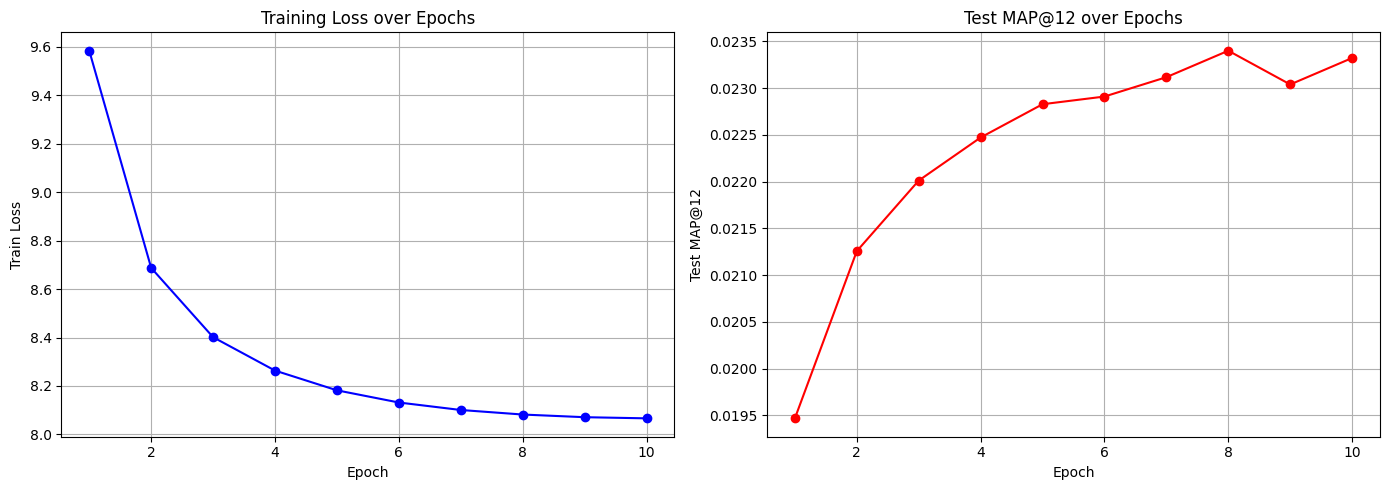


Training curves saved to 'training_results.png'


In [57]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss')
ax1.set_title('Training Loss over Epochs')
ax1.grid(True)

# MAP@12
ax2.plot(range(1, len(history['test_map']) + 1), history['test_map'], 'r-o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test MAP@12')
ax2.set_title('Test MAP@12 over Epochs')
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining curves saved to 'training_results.png'")

Sample Predictions

In [58]:
# Montrer quelques exemples de predictions
print("\nSample Predictions:\n")

model.eval()
sample_users = list(test_targets.keys())[:5]

with torch.no_grad():
    for i, user_id in enumerate(sample_users, 1):
        if user_id not in user_sequences:
            continue

        # Historique
        seq = user_sequences[user_id]
        encoded_seq = [article_to_idx.get(art, 0) for art in seq]
        encoded_seq = [x for x in encoded_seq if x != 0]

        if len(encoded_seq) == 0:
            continue

        if len(encoded_seq) > config.max_seq_len:
            encoded_seq = encoded_seq[-config.max_seq_len:]

        padded_seq = [0] * (config.max_seq_len - len(encoded_seq)) + encoded_seq
        mask = [True] * (config.max_seq_len - len(encoded_seq)) + [False] * len(encoded_seq)

        input_seq = torch.LongTensor([padded_seq]).to(device)
        mask_tensor = torch.BoolTensor([mask]).to(device)

        # Predictions
        top_k_indices = model.predict_top_k(input_seq, mask_tensor, k=12)
        top_k_indices = top_k_indices[0].cpu().numpy()

        recommended = [idx_to_article.get(idx, 'Unknown') for idx in top_k_indices]
        actual = test_targets[user_id]

        print(f"User {i}:")
        print(f"  Last 3 purchases in history: {seq[-3:]}")
        print(f"  Actually bought in test: {actual}")
        print(f"  Top 12 recommendations: {recommended}")

        # Calculer hits
        hits = [art for art in recommended if art in actual]
        print(f"  Hits: {hits if hits else 'None'}")
        print()


Sample Predictions:

User 1:
  Last 3 purchases in history: [706371005, 771602001, 771602001]
  Actually bought in test: [624486001]
  Top 12 recommendations: [np.int64(771602001), np.int64(771602002), np.int64(706365003), np.int64(774148001), np.int64(786024003), np.int64(719484004), np.int64(816083002), np.int64(770336001), np.int64(788115001), np.int64(788006001), np.int64(568601006), np.int64(724729001)]
  Hits: None

User 2:
  Last 3 purchases in history: [880017001, 880017001, 889036004]
  Actually bought in test: [827487003]
  Top 12 recommendations: [np.int64(889036004), np.int64(919273002), np.int64(898573003), np.int64(909371001), np.int64(895836003), np.int64(857924011), np.int64(927957001), np.int64(881942001), np.int64(908799002), np.int64(886557004), np.int64(904026002), np.int64(929511001)]
  Hits: None

User 3:
  Last 3 purchases in history: [576897001, 816588001, 732842015]
  Actually bought in test: [757926001, 788575004, 640021019]
  Top 12 recommendations: [np.int6

In [59]:
# Verifier combien de customers ont un historique dans train
customers_with_history = set(user_sequences.keys())
customers_to_predict = set(all_customers)

overlap = customers_with_history.intersection(customers_to_predict)
cold_start = customers_to_predict - customers_with_history

print(f"\nCustomer coverage analysis:")
print(f"  Customers with purchase history: {len(overlap)} ({len(overlap)/len(all_customers)*100:.1f}%)")
print(f"  Cold start customers (no history): {len(cold_start)} ({len(cold_start)/len(all_customers)*100:.1f}%)")


Customer coverage analysis:
  Customers with purchase history: 1356286 (98.9%)
  Cold start customers (no history): 15694 (1.1%)


In [60]:
# Compter les achats dans la periode recente (4 derniers mois de train)
recent_date = train_transactions['t_dat'].max()
one_month_ago = recent_date - timedelta(days=120)
recent_transactions = train_transactions[train_transactions['t_dat'] >= one_month_ago]

# Top articles par popularite
article_counts = recent_transactions['article_id'].value_counts()
top_popular_articles = article_counts.head(12).index.tolist()

print(f"Top 12 popular articles: {top_popular_articles[:5]}...")

Top 12 popular articles: [706016001, 372860002, 751471001, 599580038, 759871002]...


In [61]:
@torch.no_grad()
def predict_for_customer(customer_id, model, user_sequences, article_to_idx, idx_to_article,
                         top_popular_articles, device, k=12):
    """
    Genere 12 recommandations pour un customer

    Si le customer a un historique: utilise le modele
    Sinon (cold start): retourne les articles populaires
    """

    # Cas 1: Customer avec historique
    if customer_id in user_sequences:
        seq = user_sequences[customer_id]
        encoded_seq = [article_to_idx.get(art, 0) for art in seq]
        encoded_seq = [x for x in encoded_seq if x != 0]

        if len(encoded_seq) > 0:
            # Preparer input
            if len(encoded_seq) > config.max_seq_len:
                encoded_seq = encoded_seq[-config.max_seq_len:]

            padded_seq = [0] * (config.max_seq_len - len(encoded_seq)) + encoded_seq
            mask = [True] * (config.max_seq_len - len(encoded_seq)) + [False] * len(encoded_seq)

            input_seq = torch.LongTensor([padded_seq]).to(device)
            mask_tensor = torch.BoolTensor([mask]).to(device)

            # Prediction
            top_k_indices = model.predict_top_k(input_seq, mask_tensor, k=k)
            top_k_indices = top_k_indices[0].cpu().numpy()

            # Convertir en article_ids
            recommendations = []
            for idx in top_k_indices:
                article = idx_to_article.get(idx, None)
                if article is not None:
                    recommendations.append(article)

            # Si pas assez de recommendations, completer avec populaires
            if len(recommendations) < k:
                for pop_art in top_popular_articles:
                    if pop_art not in recommendations:
                        recommendations.append(pop_art)
                        if len(recommendations) >= k:
                            break

            return recommendations[:k]

    # Cas 2: Cold start - retourner articles populaires
    return top_popular_articles[:k]

print("Prediction function defined")

Prediction function defined


In [62]:
print("\nGenerating predictions for all customers...")
print("This may take several minutes...\n")

model.eval()
predictions = []

total_customers = len(all_customers)
batch_log_interval = 10000

for idx, customer_id in enumerate(all_customers, 1):
    # Generer 12 recommandations
    recommended_articles = predict_for_customer(
        customer_id,
        model,
        user_sequences,
        article_to_idx,
        idx_to_article,
        top_popular_articles,
        device,
        k=12
    )

    # Formatter: articles separes par des espaces
    prediction_str = ' '.join([str(art) for art in recommended_articles])

    predictions.append({
        'customer_id': customer_id,
        'prediction': prediction_str
    })

    # Log progress
    if idx % batch_log_interval == 0:
        print(f"  Processed {idx}/{total_customers} customers ({idx/total_customers*100:.1f}%)")

print(f"\nCompleted predictions for {len(predictions)} customers")


Generating predictions for all customers...
This may take several minutes...

  Processed 10000/1371980 customers (0.7%)
  Processed 20000/1371980 customers (1.5%)
  Processed 30000/1371980 customers (2.2%)
  Processed 40000/1371980 customers (2.9%)
  Processed 50000/1371980 customers (3.6%)
  Processed 60000/1371980 customers (4.4%)
  Processed 70000/1371980 customers (5.1%)
  Processed 80000/1371980 customers (5.8%)
  Processed 90000/1371980 customers (6.6%)
  Processed 100000/1371980 customers (7.3%)
  Processed 110000/1371980 customers (8.0%)
  Processed 120000/1371980 customers (8.7%)
  Processed 130000/1371980 customers (9.5%)
  Processed 140000/1371980 customers (10.2%)
  Processed 150000/1371980 customers (10.9%)
  Processed 160000/1371980 customers (11.7%)
  Processed 170000/1371980 customers (12.4%)
  Processed 180000/1371980 customers (13.1%)
  Processed 190000/1371980 customers (13.8%)
  Processed 200000/1371980 customers (14.6%)
  Processed 210000/1371980 customers (15.3%

In [63]:
submission_df = pd.DataFrame(predictions)

print(f"\nSubmission DataFrame:")
print(f"  Shape: {submission_df.shape}")
print(f"  Columns: {submission_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(submission_df.head())
print(f"\nLast few rows:")
print(submission_df.tail())


Submission DataFrame:
  Shape: (1371980, 2)
  Columns: ['customer_id', 'prediction']

First few rows:
                                         customer_id  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...   

                                          prediction  
0  568601043 664074001 858856005 678942001 664074...  
1  739590036 758002008 826211002 832331002 811783...  
2  794321007 794321011 805000007 805000001 866610...  
3  732413001 730683001 678687001 742079001 712711...  
4  791587015 730683050 804992014 918292001 804992...  

Last few rows:
                                               customer_id  \
1371975  ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e474...   
1371976  ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab5...   
1371977  ffffcf35913a0bee60e

In [64]:
# Verifications critiques
print("\n" + "="*60)
print("VERIFICATION BEFORE SAVING")
print("="*60)

# 1. Nombre de lignes
expected_rows = len(sample_submission)
actual_rows = len(submission_df)
print(f"\n1. Number of rows:")
print(f"   Expected: {expected_rows}")
print(f"   Actual: {actual_rows}")
print(f"   Status: {'OK' if expected_rows == actual_rows else 'ERROR'}")

# 2. Colonnes
expected_cols = ['customer_id', 'prediction']
actual_cols = submission_df.columns.tolist()
print(f"\n2. Columns:")
print(f"   Expected: {expected_cols}")
print(f"   Actual: {actual_cols}")
print(f"   Status: {'OK' if expected_cols == actual_cols else 'ERROR'}")

# 3. Customer IDs correspondent
expected_ids = set(sample_submission['customer_id'])
actual_ids = set(submission_df['customer_id'])
print(f"\n3. Customer IDs match:")
print(f"   Status: {'OK' if expected_ids == actual_ids else 'ERROR'}")

# 4. Nombre d'articles par prediction
def count_articles(pred_str):
    return len(pred_str.split())

submission_df['num_articles'] = submission_df['prediction'].apply(count_articles)
print(f"\n4. Number of articles per prediction:")
print(f"   Min: {submission_df['num_articles'].min()}")
print(f"   Max: {submission_df['num_articles'].max()}")
print(f"   Mode: {submission_df['num_articles'].mode()[0]}")
print(f"   Status: {'OK' if submission_df['num_articles'].min() == 12 else 'WARNING: Some predictions have < 12 articles'}")

# Supprimer la colonne temporaire
submission_df = submission_df.drop('num_articles', axis=1)



# 5. Pas de valeurs manquantes
null_count = submission_df.isnull().sum().sum()
print(f"\n5. Missing values:")
print(f"   Count: {null_count}")
print(f"   Status: {'OK' if null_count == 0 else 'ERROR'}")


VERIFICATION BEFORE SAVING

1. Number of rows:
   Expected: 1371980
   Actual: 1371980
   Status: OK

2. Columns:
   Expected: ['customer_id', 'prediction']
   Actual: ['customer_id', 'prediction']
   Status: OK

3. Customer IDs match:
   Status: OK

4. Number of articles per prediction:
   Min: 12
   Max: 12
   Mode: 12
   Status: OK

5. Missing values:
   Count: 0
   Status: OK


In [65]:
def pad_article_ids(prediction):
    return " ".join(article_id.zfill(10) for article_id in str(prediction).split())


In [66]:
submission_df["prediction"] = submission_df["prediction"].apply(pad_article_ids)


In [68]:
# Sauvegarder le fichier
output_filename = 'submission_20_Transactions.csv'
submission_df.to_csv(output_filename, index=False)

print(f"\n" + "="*60)
print("SUBMISSION FILE SAVED")
print("="*60)
print(f"\nFile: {output_filename}")
print(f"Size: {os.path.getsize(output_filename) / 1024 / 1024:.2f} MB")

# Verifier le fichier sauvegarde
saved_df = pd.read_csv(output_filename)
print(f"\nVerification of saved file:")
print(f"  Rows (excluding header): {len(saved_df)}")
print(f"  Columns: {saved_df.columns.tolist()}")

print(f"\n{'='*60}")
print("READY FOR SUBMISSION TO KAGGLE")
print(f"{'='*60}")



SUBMISSION FILE SAVED

File: submission_20_Transactions.csv
Size: 257.76 MB

Verification of saved file:
  Rows (excluding header): 1371980
  Columns: ['customer_id', 'prediction']

READY FOR SUBMISSION TO KAGGLE


In [69]:
# Montrer quelques exemples
print("\nSample predictions:\n")

for i in range(5):
    row = submission_df.iloc[i]
    customer_id = row['customer_id']
    articles = row['prediction'].split()

    # Verifier si le customer avait un historique
    has_history = customer_id in user_sequences

    print(f"Customer {i+1}: {customer_id}")
    print(f"  Has purchase history: {has_history}")
    if has_history:
        history = user_sequences[customer_id]
        print(f"  Last 3 purchases: {history[-3:]}")
    print(f"  Predicted articles: {articles}")
    print()


Sample predictions:

Customer 1: 00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657
  Has purchase history: True
  Last 3 purchases: [795440001, 859416011, 568601043]
  Predicted articles: ['0568601043', '0664074001', '0858856005', '0678942001', '0664074007', '0568601006', '0921226001', '0579541001', '0568601023', '0579541004', '0664074079', '0568601007']

Customer 2: 0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa
  Has purchase history: True
  Last 3 purchases: [811925005, 351484002, 826211002]
  Predicted articles: ['0739590036', '0758002008', '0826211002', '0832331002', '0811783001', '0758002011', '0806534001', '0757995011', '0687034024', '0811927007', '0687034023', '0811925011']

Customer 3: 000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318
  Has purchase history: True
  Last 3 purchases: [852643001, 852643003, 794321007]
  Predicted articles: ['0794321007', '0794321011', '0805000007', '0805000001', '0866610001', '0892892001', '086364